In [3]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


# Obnovitelné vs. Neobnovitelné elektrárny – klasifikační projekt z předmětu 4IZ566

**Cíl:**
Předpovědět, zda je elektrárna **obnovitelná** nebo **neobnovitelná** (`is_renewable`),
odvozeno z proměnné `primary_fuel` pomocí datové sady *Global Power Plant Database*.

Zdroj: https://github.com/wri/global-power-plant-database

## Struktura reportu a naplnění požadavků

Notebook je strukturovaný podle doporučené osnovy:

1. **Popis datové sady**
   - základní přehled o datové sadě, typy proměnných, počet elektráren a zemí.
2. **Exploratorní analýza dat (EDA)**
   - rozložení typů paliva (`primary_fuel`), výkonu (`capacity_mw`) a zemí.
3. **Předzpracování dat (preprocessing)**
   - odvození nových sloupců (`is_renewable`, `age`, `log1p_capacity`),
   - ošetření chybějících hodnot,
   - odstranění nehodících se/slabě vyplněných sloupců,
   - příprava numerických a kategorických příznaků.
4. **Modelování a ladění hyperparametrů**
   - dva modely: Logistická regrese a Random Forest,
   - použití GridSearchCV a křížové validace.
5. **Vyhodnocení modelu**
   - accuracy, ROC AUC,
   - klasifikační report,
   - matice záměn,
   - ROC křivka,
   - důležitost příznaků.

# Krok 1. Import knihoven a načtení datové sady

V této části:
- importujeme všechny potřebné knihovny pro analýzu a modelování,
- načteme datovou sadu **Global Power Plant Database** z relativní cesty,
- provedeme rychlou kontrolu rozměrů dat, názvů sloupců a ukázku záznamů.

In [1]:
# Potlačení zbytečných varování pro čistší výstup
import warnings
warnings.filterwarnings("ignore")


# Analýza a vizualizace dat
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nástroje pro strojové učení
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

# Pipeline z imbalanced-learn (umožňuje vložit SMOTE)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Metriky a vizualizace
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_fscore_support
)

# Modely
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Nastavení seedů pro reprodukovatelnost
SEED = 42
np.random.seed(SEED)

# Načtení dat do DataFrame
csv_path = "global_power_plant_database.csv"
df = pd.read_csv(csv_path, low_memory=False)

# Základní informace o datové sadě
print("Datová sada byla úspěšně načtena ze souboru:", csv_path)
print(f"Počet řádků: {df.shape[0]}, počet sloupců: {df.shape[1]}")
print("\nDostupné sloupce:")
print(list(df.columns))

print("\nRychlá vizuální kontrola dat:")
# Zobrazíme několik prvních řádků pro kontrolu struktury tabulky.
display(df.head(10))

# Zkontrolujeme rozložení hodnot ve sloupci 'primary_fuel'
print("\nTop 15 hodnot ve sloupci 'primary_fuel':")
print(df['primary_fuel'].value_counts().head(15))

Datová sada byla úspěšně načtena ze souboru: global_power_plant_database.csv
Počet řádků: 34936, počet sloupců: 36

Dostupné sloupce:
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']

Rychlá vizuální kontrola dat:


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.00,31.6700,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.00,31.6230,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
5,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,58.77,54.42,42.71,59.72,46.12,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
6,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION
7,AFG,Afghanistan,Pul-e-Khumri Hydroelectric Power Plant Afghani...,GEODB0040537,6.00,35.9416,68.7100,Hydro,NaN,NaN,...,21.99,21.19,18.40,25.34,19.74,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
8,AFG,Afghanistan,Sarobi Dam Hydroelectric Power Plant Afghanistan,GEODB0040535,22.00,34.5865,69.7757,Hydro,NaN,NaN,...,123.23,82.87,69.15,93.83,80.00,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
9,ALB,Albania,Bistrica 1,WRI1002169,27.00,39.9116,20.1047,Hydro,NaN,NaN,...,105.17,75.26,79.50,105.45,88.45,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1



Top 15 hodnot ve sloupci 'primary_fuel':
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64


## Krok 2. Vytvoření cílové proměnné `is_renewable`

V tomto kroku vytvoříme novou binární proměnnou `is_renewable`,
která označuje, zda elektrárna využívá obnovitelný nebo neobnovitelný zdroj energie.

Proměnná bude odvozena ze sloupce `primary_fuel`, který určuje hlavní typ paliva elektrárny.
Hodnoty odpovídající obnovitelným zdrojům (např. hydro, solar, wind, biomass, geothermal, waste, wave and tidal)
budou označeny jako 1 (obnovitelná), ostatní jako 0 (neobnovitelná).

In [2]:
# Definice množiny obnovitelných zdrojů energie
renewable_set = {
    "hydro", "solar", "wind", "geothermal", "biomass", "waste", "wave and tidal"
}

# Funkce, která převede typ paliva na binární označení (1 = obnovitelný, 0 = neobnovitelný)
def fuel_to_is_renewable(f):
    if pd.isna(f):
        return np.nan
    f_str = str(f).strip().lower()
    return 1 if f_str in renewable_set else 0

# Vytvoření nového sloupce v DataFrame
df['is_renewable'] = df['primary_fuel'].apply(fuel_to_is_renewable)
display(df.head())

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,is_renewable
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,1
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,1
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,1


Rozložení cílové proměnné (is_renewable):
is_renewable
1    25862
0     9074
Name: count, dtype: int64

Podíl jednotlivých kategorií (%):
              Počet  Podíl (%)
is_renewable                  
1             25862       74.0
0              9074       26.0


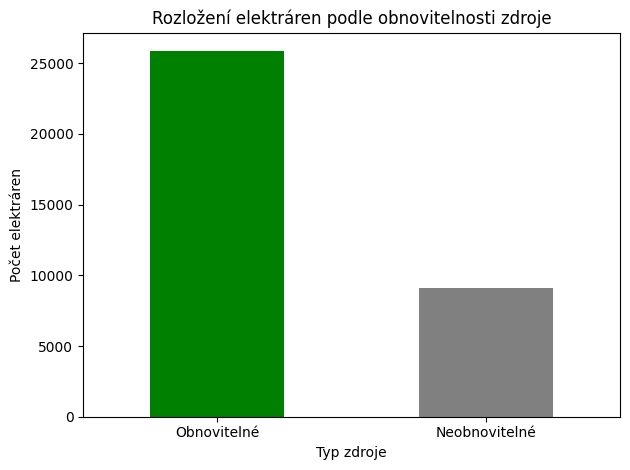

In [6]:
# Kontrola výsledného rozložení cílové proměnné
print("Rozložení cílové proměnné (is_renewable):")
print(df['is_renewable'].value_counts(dropna=False))

counts = df['is_renewable'].value_counts(dropna=False)
percents = (counts / counts.sum() * 100).round(1)
print("\nPodíl jednotlivých kategorií (%):")
print(pd.DataFrame({'Počet': counts, 'Podíl (%)': percents}))

# Vizualizace rozložení — kolik elektráren spadá do každé kategorie
plt.figure()
df['is_renewable'].value_counts().plot(kind='bar', color=['green', 'gray'])
plt.xticks([0, 1], ['Obnovitelné', 'Neobnovitelné'], rotation=0)
plt.title("Rozložení elektráren podle obnovitelnosti zdroje")
plt.xlabel("Typ zdroje")
plt.ylabel("Počet elektráren")
plt.tight_layout()
plt.show()

## Krok 3. Exploratorní analýza dat (EDA)

Cílem tohoto kroku je provést průzkumnou analýzu dat (Exploratory Data Analysis),
abychom lépe porozuměli struktuře dat a jejich hlavním vlastnostem:

- jaké typy paliva (`primary_fuel`) se v datech vyskytují a jak často,
- jaký je rozsah výkonu elektráren (`capacity_mw`),
- jak jsou elektrárny rozloženy mezi jednotlivé země.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

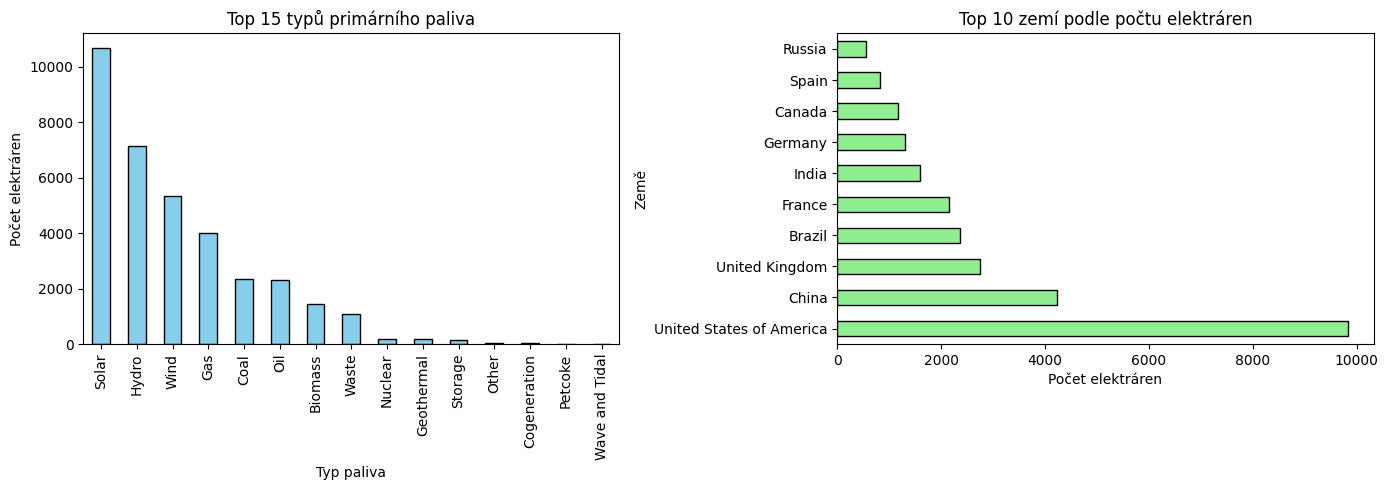

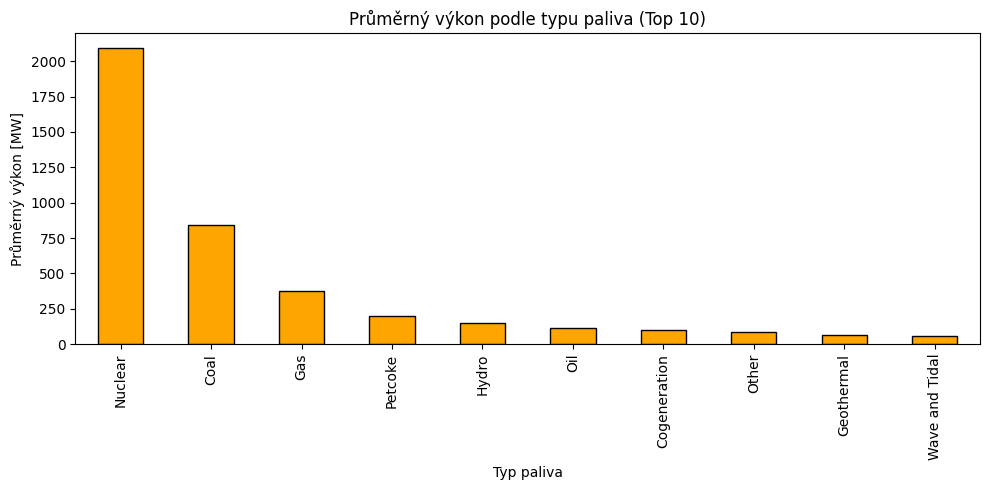

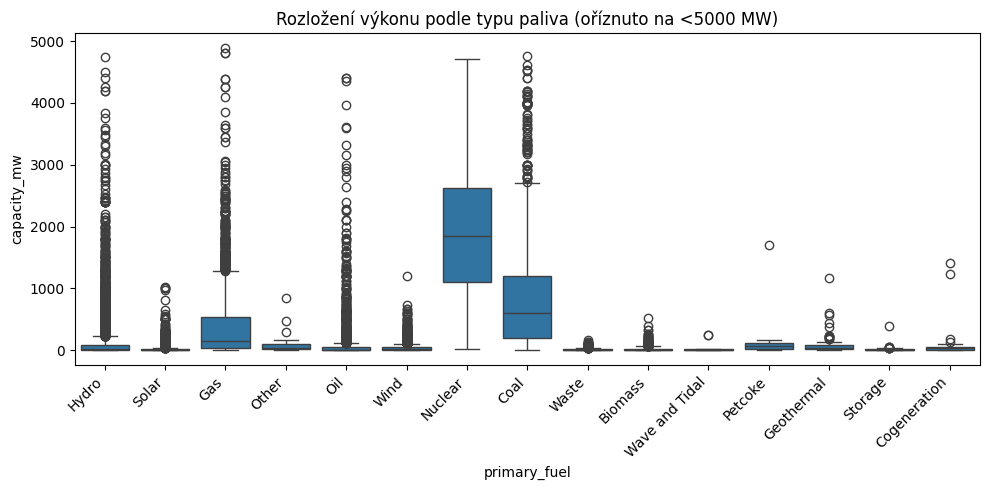

In [7]:
# Základní přehled o datové sadě
df.info()

print("\nNejčastější typy paliva:")
fuel_counts = df['primary_fuel'].value_counts().head(15)
print(fuel_counts)

# Vizualizace základních charakteristik datasetu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1. Typy paliva
fuel_counts = df['primary_fuel'].value_counts().head(15)
fuel_counts.plot(
    kind = 'bar',
    ax = axes[0],
    color = 'skyblue',
    edgecolor = 'black',
    title = 'Top 15 typů primárního paliva'
)
axes[0].set_xlabel('Typ paliva')
axes[0].set_ylabel('Počet elektráren')

# 2. Země s největším počtem elektráren
country_counts = df['country_long'].value_counts().head(10)
country_counts.plot(
    kind='barh',
    ax=axes[1],
    color='lightgreen',
    edgecolor='black',
    title='Top 10 zemí podle počtu elektráren'
)
axes[1].set_xlabel('Počet elektráren')
axes[1].set_ylabel('Země')

plt.tight_layout()
plt.show()

# Průměrný výkon podle typu paliva
plt.figure(figsize=(10,5))
df.groupby('primary_fuel')['capacity_mw'].mean().sort_values(ascending=False).head(10).plot(
    kind='bar',
    color='orange',
    edgecolor='black',
    title='Průměrný výkon podle typu paliva (Top 10)'
)
plt.ylabel('Průměrný výkon [MW]')
plt.xlabel('Typ paliva')
plt.tight_layout()
plt.show()

# Rozložení výkonu podle typu paliva
plt.figure(figsize=(10,5))
sns.boxplot(x='primary_fuel', y='capacity_mw', data=df[df['capacity_mw'] < 5000])
plt.title('Rozložení výkonu podle typu paliva (oříznuto na <5000 MW)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Krok 4. Předzpracování dat (Data Preprocessing)
V tomto kroku připravujeme data tak, aby byla vhodná pro trénování modelů:
- odstraňujeme technické a extrémně řídké sloupce, které by model pouze „zahlcovaly“,
- odvozujeme nové užitečné příznaky (`log1p_capacity`, `age`),
- validujeme souřadnice (latitude/longitude),
- rozlišujeme numerické a kategorické příznaky,
- vytvářím `ColumnTransformer`, který:
  - numerické proměnné imputuje mediánem a standardizuje,
  - kategorické proměnné imputuje nejčastější hodnotou a převádí na one-hot reprezentaci.

Celý preprocessing probíhá uvnitř pipeline, takže je bezpečně aplikován pouze na trénovací data a nedochází k úniku informací do testovací sady.

In [8]:
# Základní čistění (zahodíme technické/řídké sloupce, které se pro predikci nehodí)
drop_cols = [
    "gppd_idnr","wepp_id","url","source","geolocation_source","year_of_capacity_data",
    "name","owner",
    "other_fuel1","other_fuel2","other_fuel3",
]
# Silně řídké roční výroby a odhady
drop_cols += [c for c in df.columns if c.startswith("generation_gwh_")]
drop_cols += [c for c in df.columns if c.startswith("estimated_generation_")]
drop_cols += [c for c in df.columns if c.startswith("estimated_generation_note_")]

drop_cols = [c for c in drop_cols if c in df.columns]
df_clean = df.drop(columns=drop_cols).copy()

# Validace souřadnic (ponecháme fyzikálně možné rozsahy)
if {"latitude","longitude"}.issubset(df_clean.columns):
    df_clean = df_clean[
        df_clean["latitude"].between(-90, 90) &
        df_clean["longitude"].between(-180, 180)
    ].copy()

# Kapacita: odfiltrování neplatných hodnot + klip + log1p
if "capacity_mw" not in df_clean.columns:
    raise ValueError("Chybí sloupec 'capacity_mw'.")
df_clean = df_clean[df_clean["capacity_mw"] > 0].copy()
cap_p99 = df_clean["capacity_mw"].quantile(0.99)
df_clean["capacity_mw_clipped"] = df_clean["capacity_mw"].clip(upper=cap_p99)
df_clean["log1p_capacity"] = np.log1p(df_clean["capacity_mw_clipped"])
df_clean = df_clean.drop(columns = ["capacity_mw_clipped"])

# Сommission_year: doplnění mediánem podle skupin (země×palivo → palivo → globál)
def fill_commissioning_year(d):
    s = d["commissioning_year"].copy()
    g1 = d.groupby(["country_long","primary_fuel"])["commissioning_year"].transform("median")
    s = s.fillna(g1)
    g2 = d.groupby("primary_fuel")["commissioning_year"].transform("median")
    s = s.fillna(g2)
    s = s.fillna(d["commissioning_year"].median())
    return s

if "commissioning_year" in df_clean.columns:
    df_clean["commissioning_year_filled"] = fill_commissioning_year(df_clean)
else:
    df_clean["commissioning_year_filled"] = np.nan

# Věk elektrárny (referenční rok 2020; hodnoty rozumně omezíme)
REF_YEAR = 2020
df_clean["age"] = (REF_YEAR - df_clean["commissioning_year_filled"]).clip(lower=0, upper=80)

In [9]:
# Výběr rysů: NEpoužijeme primary_fuel (je zdrojem cíle → data leakage)

# Číselné příznaky – ponecháme jen ty, které opravdu existují
numeric_features = [
    c for c in ["log1p_capacity", "age", "latitude", "longitude"]
    if c in df_clean.columns
]

# Kategorické příznaky – např. country (můžeš si zvolit country_long místo toho)
categorical_features = [
    c for c in ["country"]  # nebo ["country_long"], pokud chceš
    if c in df_clean.columns
]

target_col = "is_renewable"

# Rychlá sanity-check
if not numeric_features and not categorical_features:
    raise ValueError("Seznam příznaků je prázdný – zkontroluj přípravu rysů výše.")
if target_col not in df_clean.columns:
    raise ValueError("Chybí cílový sloupec 'is_renewable'.")

# Sloupce, které chceme používat pro model (features + target)
feature_cols = numeric_features + categorical_features

# (Volitelné) Zahodíme pomocné sloupce, které už nechceme v modelu
cols_to_drop = []
if "commissioning_year_filled" in df_clean.columns:
    cols_to_drop.append("commissioning_year_filled")
if "primary_fuel" in df_clean.columns:
    cols_to_drop.append("primary_fuel")

if cols_to_drop:
    df_clean = df_clean.drop(columns=cols_to_drop)

# Finální "čistý" dataset pro trénování: jen příznaky + cílový sloupec
df_clean = df_clean[feature_cols + [target_col]].copy()

print("df_clean shape:", df_clean.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target col:", target_col)

df_clean.head()


df_clean shape: (34936, 6)
Numeric features: ['log1p_capacity', 'age', 'latitude', 'longitude']
Categorical features: ['country']
Target col: is_renewable


,log1p_capacity,age,latitude,longitude,country,is_renewable
0,3.526361,41.0,32.322,65.1190,AFG,1
1,2.397895,4.0,31.670,65.7950,AFG,1
2,2.397895,4.0,31.623,65.7920,AFG,1
3,4.204693,41.0,34.556,69.4787,AFG,1
4,4.615121,41.0,34.641,69.7170,AFG,1


## Krok 5. Data split
Data dělím na:
- **trénovací sadu** (80 %),
- **testovací sadu** (20 %),
pomocí `train_test_split` se zapnutou **stratifikací** podle cílové proměnné `is_renewable`.


In [10]:
X = df_clean[feature_cols]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Podíl třídy 1 v y_train:", y_train.mean().round(3))

Train shape: (27948, 5) Test shape: (6988, 5)
Podíl třídy 1 v y_train: 0.74


## Krok 6: Modelování a ladění hyperparametrů
V této části:
- stavím dvě pipeline:
  - Logistická regrese,
  - Random Forest),
- do pipeline je integrováno:
  - předzpracování (`preprocess_pipeline`),
  - vyvážení tříd pomocí SMOTE,
- pomocí GridSearchCV hledám nejlepší sadu hyperparametrů na trénovací sadě
  za použití stratifikované křížové validace.

In [11]:
# Definice ColumnTransformeru – použijeme později v modelovacím pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
])

preprocess_pipeline = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

model = Pipeline(steps=[
    ("preprocess", preprocess_pipeline),
    ("clf", RandomForestClassifier(random_state=SEED))
])


In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Křížová validace
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

# Pipeline pro oba modely
pipe_lr = ImbPipeline(steps=[
    ("preprocess", preprocess_pipeline),
    ("smote", SMOTE(random_state=SEED)),
    ("model", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs"
    )),
])

pipe_rf = ImbPipeline(steps=[
    ("preprocess", preprocess_pipeline),
    ("smote", SMOTE(random_state=SEED)),
    ("model", RandomForestClassifier(
        random_state=SEED,
        class_weight="balanced"
    )),
])

# Mřížky / distribuce hyperparametrů

# Pro LR сетка может остаться классическим GridSearch (параметров мало)
param_grid_lr = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
}

# Для RF будем использовать те же диапазоны, но через RandomizedSearch
param_dist_rf = {
    "model__max_depth": [3, 5, 8, 10, None],
    "model__n_estimators": [100, 200, 500],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", "log2"],
}

# GridSearchCV pro LR
grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

# RandomizedSearchCV pro RF
rand_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    refit=True,
    verbose=1
)

# Trénink na trénovacích datech
grid_lr.fit(X_train, y_train)
rand_rf.fit(X_train, y_train)

# Shrnutí výsledků křížové validace
print("\nVýsledky křížové validace (ROC AUC – průměr přes foldy):")

print("\nLogistická regrese (GridSearchCV):")
print("  Nejlepší parametry:", grid_lr.best_params_)
print(f"  Nejlepší průměrná AUC (LR, CV): {grid_lr.best_score_:.3f}")

print("\nRandom Forest (RandomizedSearchCV):")
print("  Nejlepší parametry:", rand_rf.best_params_)
print(f"  Nejlepší průměrná AUC (RF, CV): {rand_rf.best_score_:.3f}")


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Výsledky křížové validace (ROC AUC – průměr přes foldy):

Logistická regrese (GridSearchCV):
  Nejlepší parametry: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
  Nejlepší průměrná AUC (LR, CV): 0.836

Random Forest (RandomizedSearchCV):
  Nejlepší parametry: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
  Nejlepší průměrná AUC (RF, CV): 0.976


## Krok 7: Vyhodnocení na testovací sadě
Po nalezení nejlepších modelů (LR a RF) je vyhodnocuji na držené testovací sadě:

- počítáme accuracy a ROC AUC,
- tiskneme klasifikační report,
- vykreslujeme matice záměn pro baseline, logistickou regresi a Random Forest,
- porovnáváme ROC křivky modelů,
- analyzujeme důležitost příznaků u Random Forestu.

In [14]:
best_lr = grid_lr.best_estimator_
best_rf = rand_rf.best_estimator_

def evaluate_model(name, model, X_test, y_test):

    # Predikce tříd
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Predikce pravděpodobností (pokud model podporuje)
    auc = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)

    # Výpis výsledků
    print(f"{name} – Test Accuracy: {acc:.4f}" +
          (f", Test ROC AUC: {auc:.4f}" if auc is not None else ""))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))


# Vyhodnocení obou modelů
evaluate_model("Logistic Regression", best_lr, X_test, y_test)
evaluate_model("Random Forest", best_rf, X_test, y_test)

Logistic Regression – Test Accuracy: 0.7553, Test ROC AUC: 0.8422

Confusion matrix:
[[1347  468]
 [1242 3931]]

Classification report:
              precision    recall  f1-score   support

           0      0.520     0.742     0.612      1815
           1      0.894     0.760     0.821      5173

    accuracy                          0.755      6988
   macro avg      0.707     0.751     0.717      6988
weighted avg      0.797     0.755     0.767      6988

Random Forest – Test Accuracy: 0.9345, Test ROC AUC: 0.9789

Confusion matrix:
[[1645  170]
 [ 288 4885]]

Classification report:
              precision    recall  f1-score   support

           0      0.851     0.906     0.878      1815
           1      0.966     0.944     0.955      5173

    accuracy                          0.934      6988
   macro avg      0.909     0.925     0.917      6988
weighted avg      0.936     0.934     0.935      6988



In [15]:
# Baseline model (DummyClassifier)
baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=SEED
)
baseline.fit(X_train, y_train)
evaluate_model("Baseline (most_frequent)", baseline, X_test, y_test)

Baseline (most_frequent) – Test Accuracy: 0.7403, Test ROC AUC: 0.5000

Confusion matrix:
[[   0 1815]
 [   0 5173]]

Classification report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      1815
           1      0.740     1.000     0.851      5173

    accuracy                          0.740      6988
   macro avg      0.370     0.500     0.425      6988
weighted avg      0.548     0.740     0.630      6988



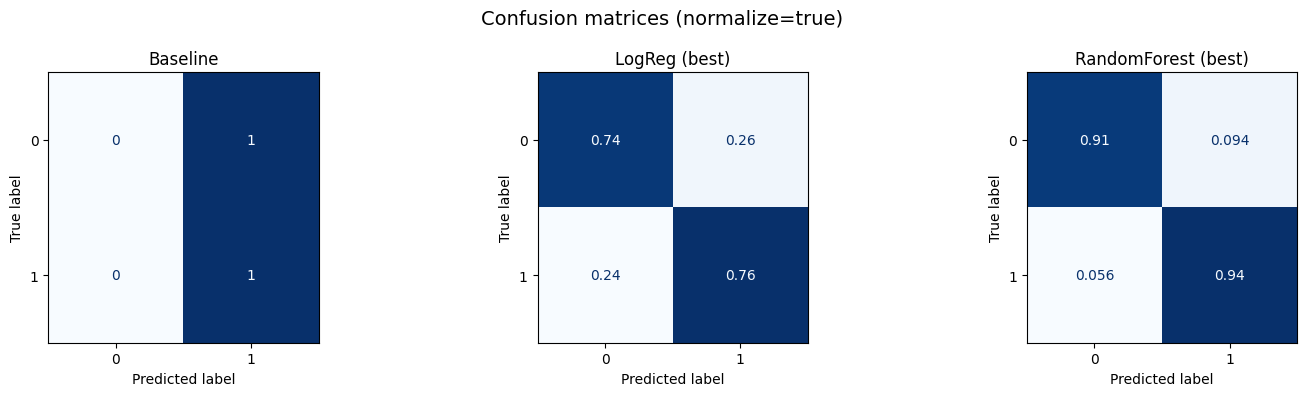

In [16]:
def plot_confusion_matrices(models, X_test, y_test, normalize="true"):
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    # Pokud je jen jeden model → axes není list, tak ho obalíme
    if n == 1:
        axes = [axes]

    for ax, (name, estimator) in zip(axes, models):
        ConfusionMatrixDisplay.from_estimator(
            estimator,
            X_test,
            y_test,
            normalize=normalize,
            cmap="Blues",
            ax=ax,
            colorbar=False
        )
        ax.set_title(name)

    fig.suptitle(f"Confusion matrices (normalize={normalize})", fontsize=14)
    plt.tight_layout()
    plt.show()


# Modely, které chceme zobrazit
models_to_plot = []

# 1) Nejdříve přidáme baseline, pokud existuje proměnná `baseline`
if "baseline" in globals():
    models_to_plot.append(("Baseline", baseline))

# 2) Poté přidáme nejlepší modely z GridSearchCV
models_to_plot.extend([
    ("LogReg (best)", best_lr),
    ("RandomForest (best)", best_rf),
])

# Vykreslení matic (normalizace podle skutečných tříd)
plot_confusion_matrices(models_to_plot, X_test, y_test, normalize="true")


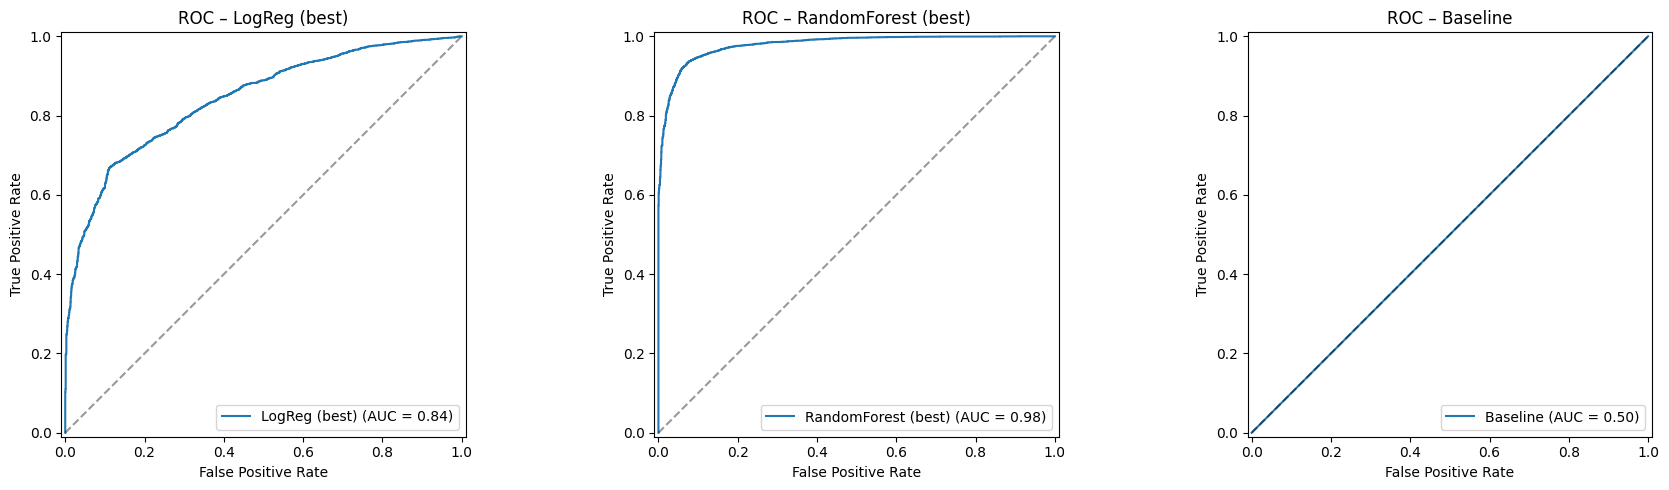

In [17]:
# 6.8 ROC křivky
# Připravíme si seznam modelů
models_for_roc = [
    ("LogReg (best)", best_lr),
    ("RandomForest (best)", best_rf),
]

# Pokud existuje baseline a podporuje predict_proba → přidáme
if "baseline" in globals() and hasattr(baseline, "predict_proba"):
    models_for_roc.append(("Baseline", baseline))

n = len(models_for_roc)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

# Pokud je jen jeden model → aby axes byl list
if n == 1:
    axes = [axes]

# Kreslení jednotlivých ROC křivek
for ax, (name, model) in zip(axes, models_for_roc):
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=name
    )
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(f"ROC – {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

plt.tight_layout()
plt.show()


In [18]:
# Porovnání a interpretace modelů
# Seznam modelů k porovnání
models_to_compare = []

# Přidáme baseline, pokud existuje
if "baseline" in globals():
    models_to_compare.append(("Baseline", baseline))

# Nejlepší modely z GridSearchCV
models_to_compare.extend([
    ("LogReg (best)", best_lr),
    ("RandomForest (best)", best_rf),
])


def summarize_models(models, X_test, y_test):
    """
    Pomocná funkce:
    Pro každý model spočítá základní metriky na testovací sadě
    a vrátí je jako pandas DataFrame.
    """
    rows = []

    for name, est in models:
        # Predikce tříd
        y_pred = est.predict(X_test)

        # Přesnost (accuracy)
        acc = accuracy_score(y_test, y_pred)

        # Vážené precision/recall/F1 (bere v úvahu nevyváženost tříd)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0,
        )

        # ROC AUC (pokud model umí vracet pravděpodobnosti)
        auc = np.nan
        if hasattr(est, "predict_proba"):
            try:
                y_proba = est.predict_proba(X_test)[:, 1]
                auc = roc_auc_score(y_test, y_proba)
            except Exception:
                auc = np.nan

        rows.append({
            "model":      name,
            "accuracy":   acc,
            "precision_w": prec,
            "recall_w":    rec,
            "f1_w":        f1,
            "roc_auc":     auc,
        })

    return pd.DataFrame(rows)


# Vytvoření přehledové tabulky
summary_df = summarize_models(models_to_compare, X_test, y_test)

# Seřadíme modely podle kvality (nejdřív nejlepší AUC, pak F1 a accuracy)
summary_df = summary_df.sort_values(
    by=["roc_auc", "f1_w", "accuracy"],
    ascending=False
)

# Hezčí výpis s formátováním
display(
    summary_df.style.format({
        "accuracy":   "{:.4f}",
        "precision_w": "{:.4f}",
        "recall_w":    "{:.4f}",
        "f1_w":        "{:.4f}",
        "roc_auc":     "{:.4f}",
    }).set_caption("Porovnání modelů na testu")
)

,model,accuracy,precision_w,recall_w,f1_w,roc_auc
2,RandomForest (best),0.9345,0.9364,0.9345,0.9351,0.9789
1,LogReg (best),0.7553,0.7966,0.7553,0.7669,0.8422
0,Baseline,0.7403,0.5480,0.7403,0.6298,0.5000


In [21]:
# Kontrola přeučení (overfitting)

# Predikce na trénovací sadě
y_pred_train = best_rf.predict(X_train)
y_proba_train = best_rf.predict_proba(X_train)[:, 1]

train_acc = accuracy_score(y_train, y_pred_train)
train_auc = roc_auc_score(y_train, y_proba_train)

# Predikce na testovací sadě
test_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

print(f"TRAIN accuracy: {train_acc:.4f}")
print(f"TRAIN AUC:      {train_auc:.4f}")
print(f"TEST AUC:       {test_auc:.4f}")

TRAIN accuracy: 0.9962
TRAIN AUC:      0.9999
TEST AUC:       0.9789


## Výsledky a závěry

Analýza potvrdila, že nejúspěšnějším modelem pro predikci obnovitelnosti elektrárny je Random Forest, který na testovací sadě dosáhl ROC AUC okolo 0.98 a váženého F1-skóre přibližně 0.93. Tím výrazně překonal jak základní baseline, tak i optimalizovanou logistickou regresi.

Model Random Forest dokáže efektivně zachytit nelineární vztahy v datech. Mezi nejdůležitější prediktory patří věk elektrárny, logaritmicky upravená kapacita, geografická poloha a země. To odpovídá reálným energetickým trendům.

Dobré výsledky modelu umožnilo také pečlivé předzpracování dat: doplnění chybějících hodnot, transformace kapacity, standardizace, OneHot kódování zemí a použití SMOTE pro vyrovnání tříd.

Při ladění hyperparametrů byly použity metody GridSearchCV a RandomizedSearchCV, které umožnily systematicky prozkoumat různé konfigurace modelů a nalézt jejich optimální nastavení. GridSearch byl využit pro jednodušší model logistické regrese, zatímco RandomizedSearch se ukázal jako efektivnější u Random Forest díky velkému prostoru hyperparametrů a výrazně zkrátil dobu výpočtu bez ztráty kvality.

Do budoucna může být výkon ještě zlepšen použitím pokročilejších modelů, hlubší analýzou chyb nebo rozšířením datasetu o další rysy.

Random Forest tak představuje robustní a prakticky použitelný model pro predikci obnovitelnosti energetických zdrojů.